# E-commerce Data Analysis Using Online Retail Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df = df.dropna()
df = df[df['Quantity'] > 0]

In [4]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

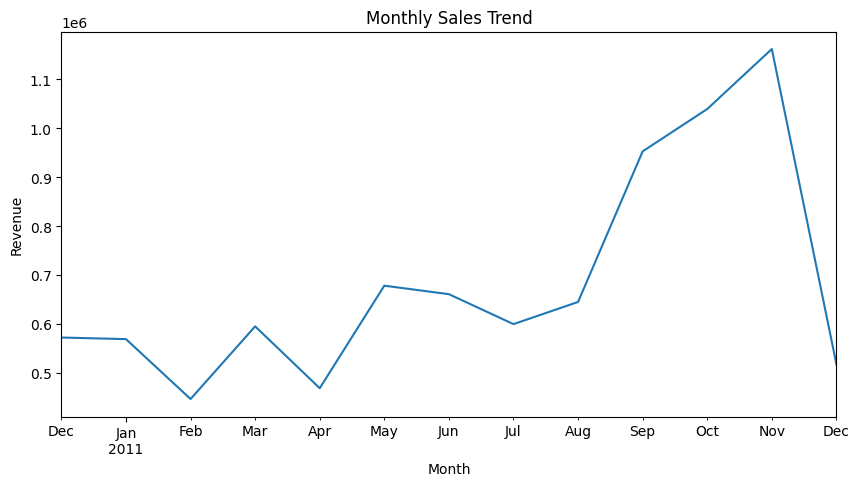

In [5]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Insight
Sales show seasonal variation with peaks during holiday months, indicating strong seasonal purchasing behavior.

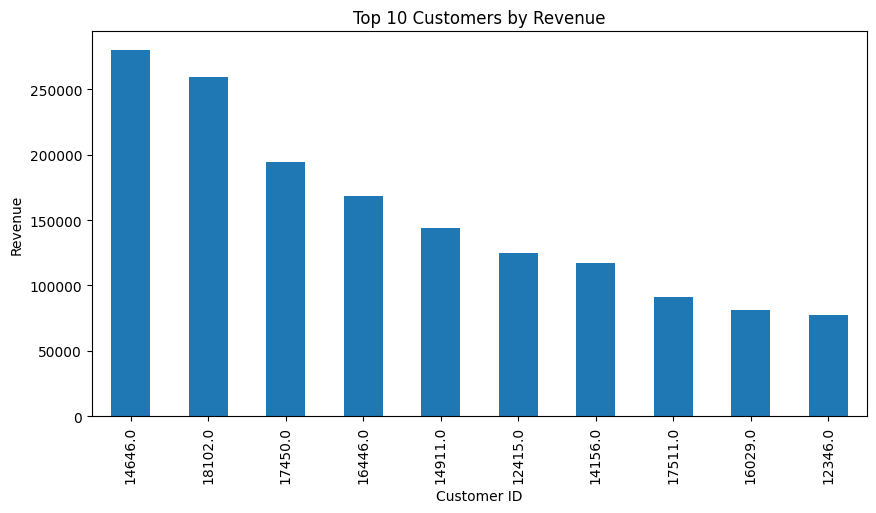

In [6]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

## Insight  
A small group of customers contributes a significant portion of total revenue, indicating strong customer concentration and potential for targeted retention strategies.

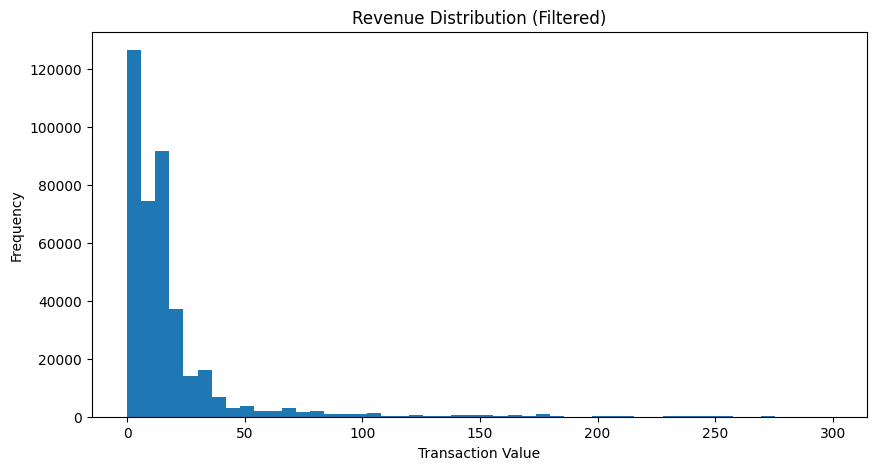

In [7]:
df_filtered = df[df['TotalPrice'] < 300]

plt.figure(figsize=(10,5))
plt.hist(df_filtered['TotalPrice'], bins=50)
plt.title("Revenue Distribution (Filtered)")
plt.xlabel("Transaction Value")
plt.ylabel("Frequency")
plt.show()

## Insight  
Most transactions fall within a lower price range, while a small number of high-value purchases contribute disproportionately to total revenue.